In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# pos = pd.read_csv('data/raw/player_positions/player_positions.csv')
s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26 = pd.concat([s26, p26])
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
62,2025-26,1627747,Caris LeVert,Caris,1610612765,DET,Detroit Pistons,42500101,2026-04-19T00:00:00,DET vs. ORL,L,4.416667,1,1,1.000,1,1,1.000,0,0,0.0,0,3,3,1,0,0,1,0,1,0,3,1,11.1,0,0,10.0,1,4:25,1,117.8,127.3,127.3,126.0,118.2,118.2,-8.1,9.1,9.1,0.250,0.0,50.0,0.0,0.375,0.231,0.0,0.0,1.500,1.500,0.083,0.084,120.63,119.55,99.62,119.55,0.250,11,1.0,1.0,31,77,0.403,10,32,0.313,29,38,0.763,6,33,39,19,14.0,9,6,6,17,24,101,-11.0,99.3,103.1,112.7,113.1,-13.4,-10.1,0.613,1.36,14.7,0.245,0.702,0.469,0.143,0.468,0.539,100.5,98.5,82.08,98,0.440,1610612753,ORL,Orlando Magic,44,90,0.489,10,34,0.294,14,19,0.737,11,34,45,26,12.0,11,6,6,24,17,112,11.0,112.7,113.1,99.3,103.1,13.4,10.1,0.591,2.17,18.7,0.298,0.755,0.531,0.121,0.544,0.569,100.5,98.5,82.08,99,0.560,NaN,SG,31.0,NaN
63,2025-26,1641775,Jordan Walsh,Jordan,1610612738,BOS,Boston Celtics,42500111,2026-04-19T00:00:00,BOS vs. PHI,W,14.666667,2,5,0.400,1,3,0.333,0,2,0.0,0,2,2,2,0,0,0,0,0,2,5,14,10.4,0,0,10.0,1,14:40,1,113.8,123.3,123.3,82.9,79.3,79.3,30.9,44.0,44.0,0.182,0.0,25.0,0.0,0.125,0.063,0.0,0.0,0.500,0.425,0.171,0.170,98.64,96.55,80.45,96.55,0.082,30,2.0,5.0,45,90,0.500,16,44,0.364,17,22,0.773,5,38,43,31,10.0,7,3,1,21,20,123,32.0,117.5,126.8,87.4,93.8,30.1,33.0,0.689,3.10,21.8,0.313,0.719,0.533,0.103,0.589,0.617,104.4,97.0,80.83,97,0.697,1610612755,PHI,Philadelphia 76ers,35,90,0.389,4,23,0.174,17,23,0.739,11,29,40,20,15.0,3,1,3,20,21,91,-32.0,87.4,93.8,117.5,126.8,-30.1,-33.0,0.571,1.33,15.0,0.281,0.688,0.467,0.155,0.411,0.454,104.4,97.0,80.83,97,0.303,NaN,PF,21.0,NaN
64,2025-26,1631248,Baylor Scheierman,Baylor,1610612738,BOS,Boston Celtics,42500111,2026-04-19T00:00:00,BOS vs. PHI,W,15.283333,2,5,0.400,1,3,0.333,0,0,0.0,0,2,2,0,0,0,1,0,1,1,5,8,10.4,0,0,10.0,1,15:17,1,117.4,119.4,119.4,86.5,90.6,90.6,30.9,28.7,28.7,0.000,0.0,0.0,0.0,0.125,0.065,0.0,0.0,0.500,0.500,0.147,0.149,102.13,98.93,82.44,98.93,0.069,31,2.0,5.0,45,90,0.500,16,44,0.364,17,22,0.773,5,38,43,31,10.0,7,3,1,21,20,123,32.0,117.5,126.8,87.4,93.8,30.1,33.0,0.689,3.10,21.8,0.313,0.719,0.533,0.103,0.589,0.617,104.4,97.0,80.83,97,0.697,1610612755,PHI,Philadelphia 76ers,35,90,0.389,4,23,0.174,17,23,0.739,11,29,40,20,15.0,3,1,3,20,21,91,-32.0,87.4,93.8,117.5,126.8,-30.1,-33.0,0.571,1.33,15.0,0.281,0.688,0.467,0.155,0.411,0.454,104.4,97.0,80.83,97,0.303,NaN,SG,25.0,NaN
44,2025-26,1629130,Duncan Robinson,Duncan,1610612765,DET,Detroit Pistons,

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    df = min_features(df)

    df['TEAM_MIN_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))

    # Calculate the player's personal season-to-date baseline
    player_stats = df.groupby('PLAYER_ID')['MIN']
    # Use expanding() to avoid look-ahead bias (only uses games played UP TO that date)
    df['MIN_SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    df['MIN_SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    # The Z-score of their current 10-game average relative to their own season
    df['MIN_ROLE_Z_SCORE'] = (df['MIN_roll10'] - df['MIN_SEASON_MEAN']) / df['MIN_SEASON_STD']
    df['MIN_VOLATILITY_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(
    lambda x: x.rolling(window=10, min_periods=1).std().shift(1))
    df['MIN_VOLATILITY_RELATIVE'] = df['MIN_VOLATILITY_L10'] / df['MIN_roll10']
        
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df['ROLE_LOCK'] = (
    df['STARTER_ROLL10_PCT'] * df['MIN_std10'].apply(lambda x: 1/x))  # high start% + low variance = locked in role = safest bet
    df['ROLE_SHOCK'] = (df['MIN_5_ewm'] - df['MIN_10_ewm']) / df['MIN_10_ewm']                            # normalized as % change


    df['MIN_MIN_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).min())
    df['MIN_MAX_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).max())

    
    df = df[(df['MIN'] > 0) & (df['MIN'] < 48)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.sample(10)

(105389, 274)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,MIN_roll3,PTS_roll3,PLUS_MINUS_roll3,PF_roll3,POSS_roll3,PIE_roll3,USG_PCT_roll3,TS_PCT_roll3,NET_RATING_roll3,MIN_roll5,PTS_roll5,PLUS_MINUS_roll5,PF_roll5,POSS_roll5,PIE_roll5,USG_PCT_roll5,TS_PCT_roll5,NET_RATING_roll5,MIN_roll10,PTS_roll10,PLUS_MINUS_roll10,PF_roll10,POSS_roll10,PIE_roll10,USG_PCT_roll10,TS_PCT_roll10,NET_RATING_roll10,MIN_3_ewm,PTS_3_ewm,PLUS_MINUS_3_ewm,PF_3_ewm,POSS_3_ewm,PIE_3_ewm,USG_PCT_3_ewm,TS_PCT_3_ewm,NET_RATING_3_ewm,MIN_5_ewm,PTS_5_ewm,PLUS_MINUS_5_ewm,PF_5_ewm,POSS_5_ewm,PIE_5_ewm,USG_PCT_5_ewm,TS_PCT_5_ewm,NET_RATING_5_ewm,MIN_10_ewm,PTS_10_ewm,PLUS_MINUS_10_ewm,PF_10_ewm,POSS_10_ewm,PIE_10_ewm,USG_PCT_10_ewm,TS_PCT_10_ewm,NET_RATING_10_ewm,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_ewm_season_avg,PTS_ewm_season_avg,PLUS_MINUS_ewm_season_avg,PF_ewm_season_avg,POSS_ewm_season_avg,PIE_ewm_season_avg,USG_PCT_ewm_season_avg,TS_PCT_ewm_season_avg,NET_RATING_ewm_season_avg,TEAM_PACE_roll10,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,MIN_std5,MIN_std20,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_NET_RATING_roll5,OPP_NET_RATING_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,TEAM_MIN_RANK_BY_POS_L10,TEAM_USG_RANK_BY_POS_L10,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,MIN_SEASON_MEAN,MIN_SEASON_STD,MIN_ROLE_Z_SCORE,MIN_VOLATILITY_L10,MIN_VOLATILITY_RELATIVE,GP,ROLE_LOCK,ROLE_SHOCK,MIN_MIN_L10,MIN_MAX_L10,START_POSITION
57976,2024-25,1627751,Jakob Poeltl,Jakob,1610612761,TOR,Toronto Raptors,22400261,2024-11-21,TOR vs. MIN,W,28.783333,5,8,0.625,0,0,0.000,5,8,0.625,3,9,12,2,0,0,0,1,4,4,15,0,32.4,1,0,29.0,1,28:47,1,114.9,109.8,109.8,109.2,109.8,109.8,5.7,0.0,0.0,0.118,0.00,14.3,0.125,0.265,0.207,0.0,0.0,0.625,0.651,0.185,0.185,99.79,101.73,84.77,101.73,0.159,61,5.0,8.0,37,72,0.514,7,23,0.304,29,39,0.744,10,33,43,22,17.0,11,1,5,24,24,110,5.0,114.4,112.2,103.4,107.1,11.0,5.1,0.595,1.29,16.8,0.256,0.700,0.495,0.173,0.563,0.617,98.8,98.0,81.67,98,0.555,1610612750,MIN,Minnesota Timberwolves,33,80,0.413,12,35,0.343,27,33,0.818,10,30,40,16,17.0,12,5,1,24,24,105,-5.0,103.4,107.1,114.4,112.2,-11.0,-5.1,0.485,0.94,12.4,0.300,0.744,0.505,0.173,0.488,0.555,98.8,

In [ ]:
# df.to_csv('data/processed/training/S26_TRAINING_MIN.csv', index=False)

In [4]:
MIN_FEATURES = [
    'GP',                      
    'STARTING',     
    'STARTING_lag1',         
    'STARTER_ROLL10_PCT',
    'MIN_ewm_season_avg',
    'TEAM_MIN_RANK_L10',     
    'MIN_10_ewm',           
    'MIN_lag1',             
    'ROLE_LOCK',              
    'TEAM_USG_RANK_L10',    
    'MIN_ROLE_Z_SCORE',                         
    'POSS_10_ewm',       
    'MIN_MAX_L10',          
    'MIN_MIN_L10',      
    'MIN_SEASON_STD',           
]

### NaN Percentage by feature

In [5]:
na_rate = df[MIN_FEATURES].isna().mean().sort_values(ascending=False)
na_rate.head(20)

ROLE_LOCK             0.201311
MIN_MAX_L10           0.201311
MIN_MIN_L10           0.201311
STARTER_ROLL10_PCT    0.063565
MIN_ewm_season_avg    0.063565
TEAM_MIN_RANK_L10     0.063565
TEAM_USG_RANK_L10     0.063565
MIN_ROLE_Z_SCORE      0.063565
MIN_SEASON_STD        0.042642
STARTING_lag1         0.021454
MIN_10_ewm            0.021454
MIN_lag1              0.021454
POSS_10_ewm           0.021454
STARTING              0.001698
GP                    0.000000
dtype: float64

In [6]:
from sklearn.model_selection import TimeSeriesSplit

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[MIN_FEATURES + ["MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[MIN_FEATURES]
y = ppm_df["MIN"]

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1378,
    max_depth          = 6,
    learning_rate      = 0.012114761889717784,
    subsample          = 0.658891356913107,
    colsample_bytree   = 0.6610449450867388,
    reg_alpha          = 0.35062788508631587,
    reg_lambda         = 0.7792871271834488,
    min_child_weight   = 4,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Training data size: {len(X)}")

tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Training data size: 105389
TSCV fold 1                    | MAE: 4.602 | R²: 0.689 | 80% Coverage: 78.6%
TSCV fold 2                    | MAE: 4.608 | R²: 0.715 | 80% Coverage: 77.5%
TSCV fold 3                    | MAE: 4.344 | R²: 0.728 | 80% Coverage: 80.0%
TSCV fold 4                    | MAE: 4.598 | R²: 0.673 | 80% Coverage: 79.4%
TSCV fold 5                    | MAE: 4.507 | R²: 0.660 | 80% Coverage: 80.2%

TimeSeriesSplit Summary
  MAE      : 4.532 ± 0.101
  R²       : 0.693  ± 0.025
  Coverage : 79.1% ± 1.0%  (target ~80%)


### Phase 2: Walk-Forward Validation

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")

WF fold 1 (2024-10-25 00:00:00 → 2025-01-04 00:00:00) | MAE: 4.400 | R²: 0.726 | 80% Coverage: 80.0%
WF fold 2 (2025-01-04 00:00:00 → 2025-03-15 00:00:00) | MAE: 4.314 | R²: 0.724 | 80% Coverage: 80.0%
WF fold 3 (2025-03-15 00:00:00 → 2025-11-24 00:00:00) | MAE: 4.700 | R²: 0.657 | 80% Coverage: 78.8%
WF fold 4 (2025-11-24 00:00:00 → 2026-02-03 00:00:00) | MAE: 4.323 | R²: 0.693 | 80% Coverage: 80.3%

Walk-Forward Summary
  MAE      : 4.434 ± 0.157
  R²       : 0.700  ± 0.028
  Coverage : 79.8% ± 0.6%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2024-10-25 00:00:00 → 2025-01-04 00:00:00) 4.400  █████████████████
  WF fold 2 (2025-01-04 00:00:00 → 2025-03-15 00:00:00) 4.314  █████████████████
  WF fold 3 (2025-03-15 00:00:00 → 2025-11-24 00:00:00) 4.700  ██████████████████
  WF fold 4 (2025-11-24 00:00:00 → 2026-02-03 00:00:00) 4.323  █████████████████


### Residual Visuals

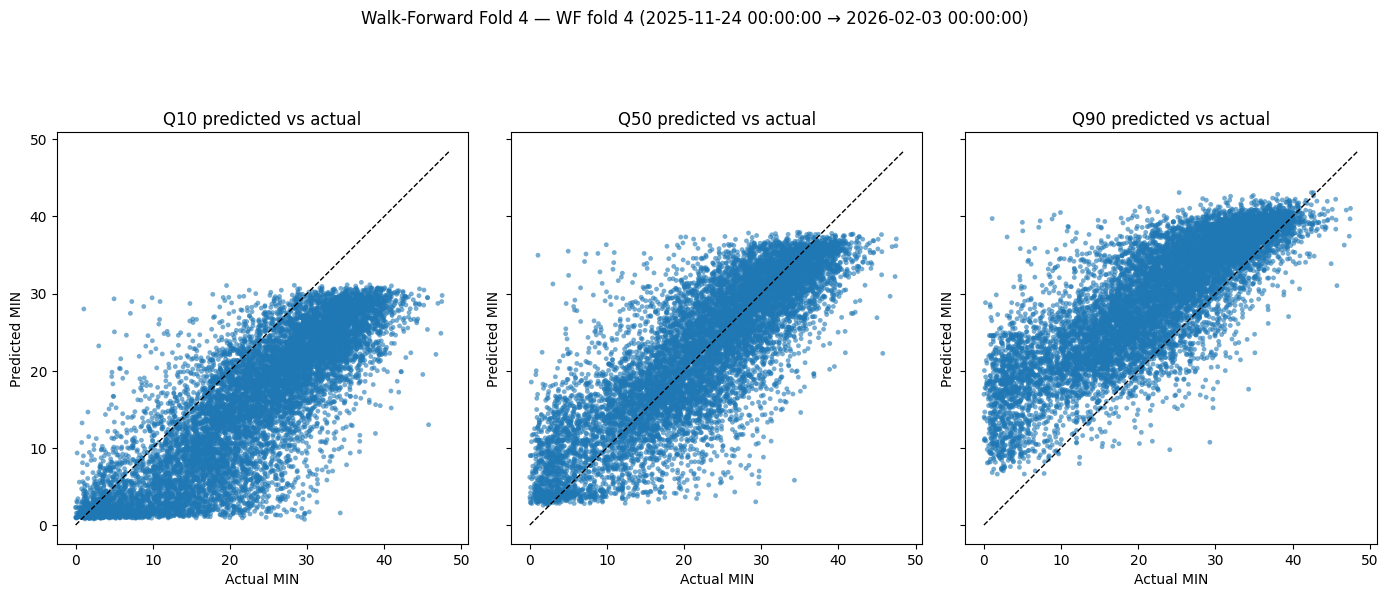

Coverage per quantile (should match quantile value):
  Q10: 10.4%  (target 10%, delta +0.4%)
  Q50: 50.5%  (target 50%, delta +0.5%)
  Q90: 90.7%  (target 90%, delta +0.7%)

80% interval width (Q10→Q90):
  mean : 13.90 min
  median: 13.56 min
  std  : 2.55 min


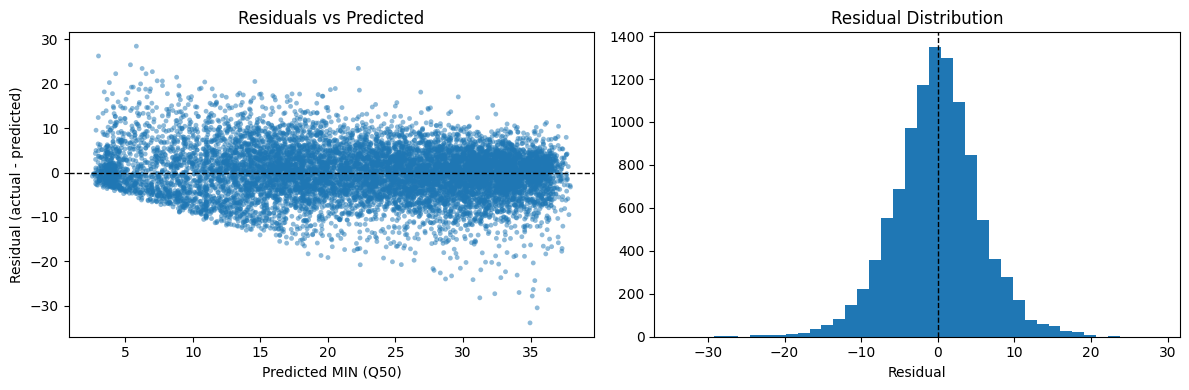


Residual summary:
  mean bias : -0.137 min  (close to 0 = unbiased)
  std       : 5.703 min


In [8]:
import matplotlib.pyplot as plt

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

In [9]:
ppm_df = df[MIN_FEATURES + ["MIN", "GAME_DATE", "PLAYER_NAME"]].sort_values("GAME_DATE").reset_index(drop=True)

val_df = ppm_df.iloc[train_end:val_end].reset_index(drop=True)

player_col = "PLAYER_NAME" if "PLAYER_NAME" in val_df.columns else None
if player_col is None:
    raise ValueError("Add PLAYER_NAME to ppm_df columns (see comment above).")

pred50 = np.asarray(pred_mid).reshape(-1)

out = pd.DataFrame({
    "player": val_df[player_col].values,
    "actual_min": np.asarray(y_true).reshape(-1),
    "pred_min_q50": pred50,
})
out["error"] = out["actual_min"] - out["pred_min_q50"]
out["abs_error"] = out["error"].abs()

# optional: tie-break sort
if "GAME_DATE" in val_df.columns:
    out["game_date"] = val_df["GAME_DATE"].values

print(out.sort_values("abs_error", ascending=True).head(20).to_string(index=False))
print(f"\nMAE (Q50): {out['abs_error'].mean():.3f} | RMSE: {np.sqrt((out['error']**2).mean()):.3f}")

                  player  actual_min  pred_min_q50     error  abs_error  game_date
          Karlo Matković   13.790000     13.789397  0.000603   0.000603 2026-02-02
         Anfernee Simons   25.700000     25.698910  0.001090   0.001090 2026-01-07
           Cedric Coward   27.450000     27.451780 -0.001780   0.001780 2026-01-15
           Jarrett Allen   28.166667     28.169327 -0.002660   0.002660 2026-01-10
             LaMelo Ball   28.250000     28.252882 -0.002882   0.002882 2026-01-22
              Malik Monk   19.000000     18.995518  0.004482   0.004482 2025-12-27
Yanic Konan Niederhäuser    3.666667      3.661861  0.004806   0.004806 2025-12-15
             Deni Avdija   35.823333     35.817879  0.005455   0.005455 2026-01-09
         Lauri Markkanen   36.200000     36.205597 -0.005597   0.005597 2025-12-22
           Norman Powell   32.283333     32.289017 -0.005683   0.005683 2025-12-05
             Jamal Shead   30.300000     30.294029  0.005971   0.005971 2026-01-20
    


── q_0.10 ──


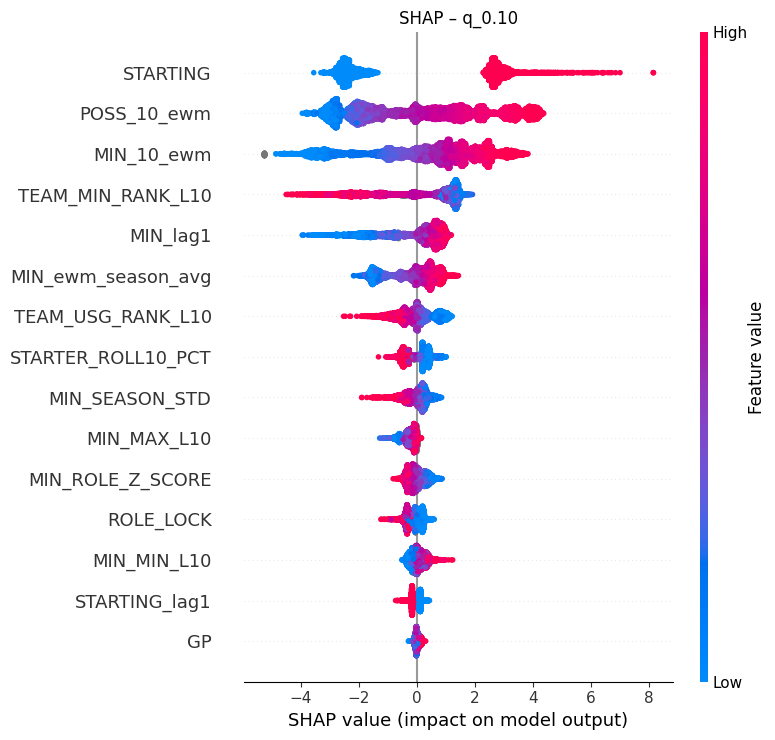


── q_0.50 ──


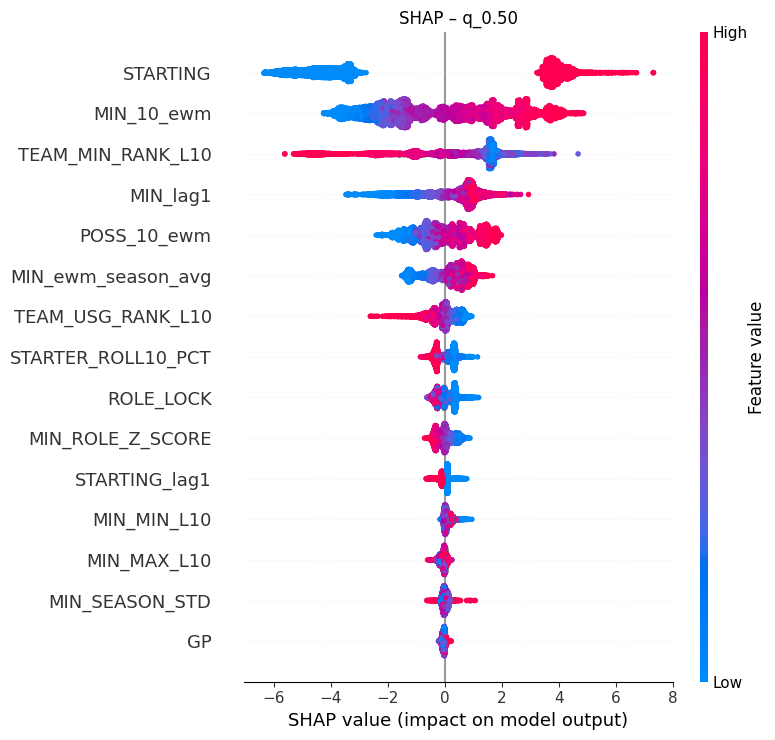


── q_0.90 ──


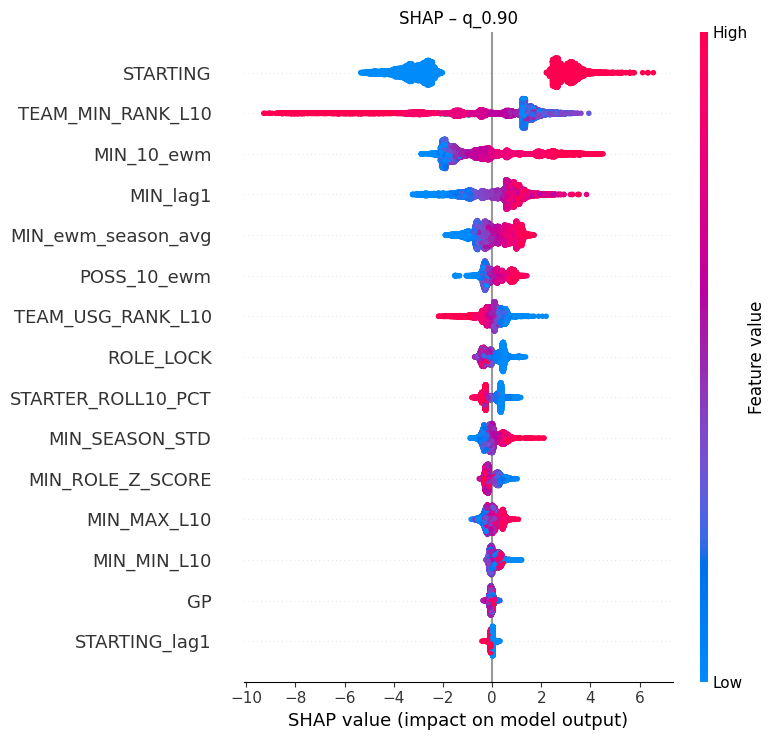

In [10]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

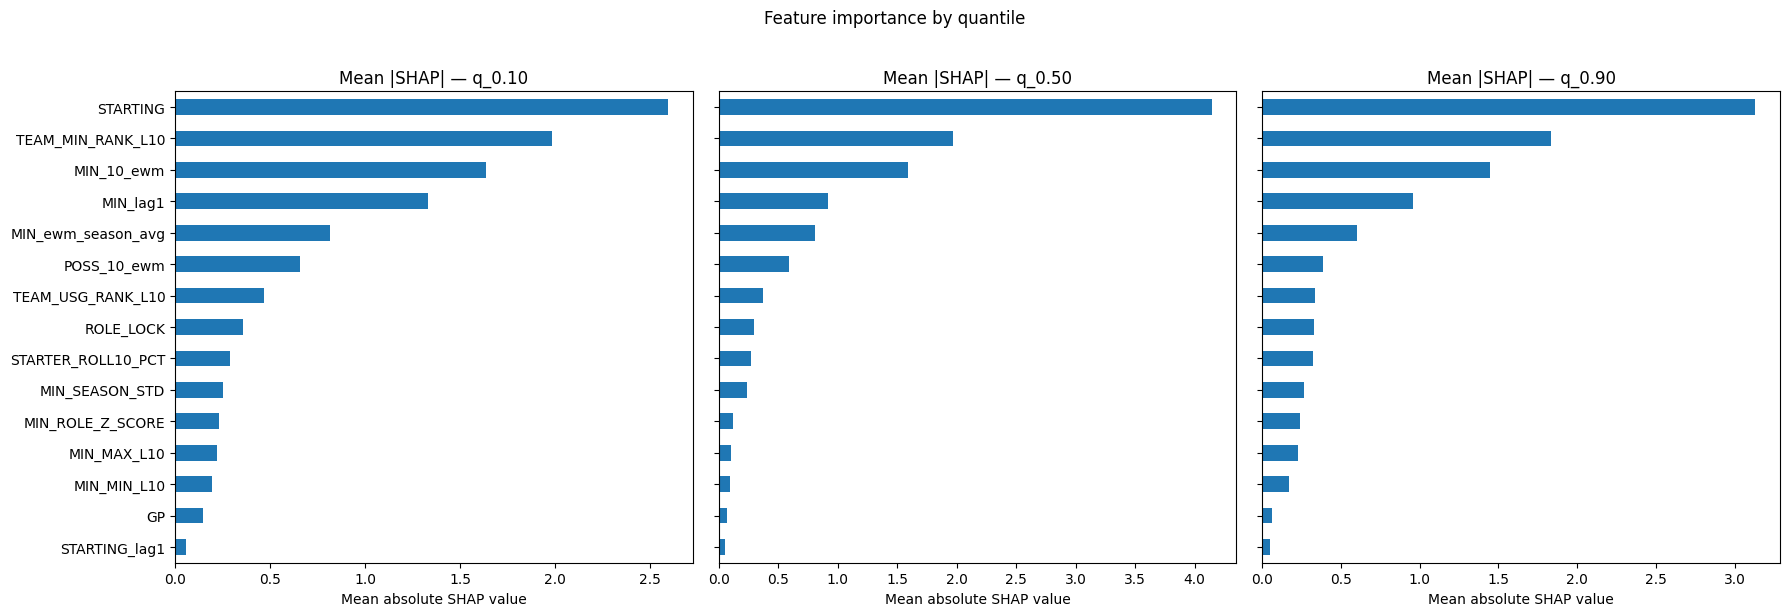

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (q_key, model) in zip(axes, models_last.items()):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feat_imp      = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

    feat_imp.plot(kind="barh", ax=ax)
    ax.set_title(f"Mean |SHAP| — {q_key}")
    ax.set_xlabel("Mean absolute SHAP value")

plt.suptitle("Feature importance by quantile", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
explainer_low  = shap.TreeExplainer(models_last["q_0.10"])
explainer_high = shap.TreeExplainer(models_last["q_0.90"])

shap_low  = explainer_low(X_val_last).values
shap_high = explainer_high(X_val_last).values

divergence = pd.Series(
    np.abs(shap_high - shap_low).mean(axis=0),
    index=MIN_FEATURES
).sort_values(ascending=False)

print("\nFeatures driving Q10 vs Q90 spread (uncertainty drivers):")
print(divergence.head(10).to_string())


Features driving Q10 vs Q90 spread (uncertainty drivers):
POSS_10_ewm           1.604010
MIN_10_ewm            1.252363
TEAM_MIN_RANK_L10     0.792896
STARTING              0.688642
MIN_SEASON_STD        0.548424
MIN_lag1              0.365800
MIN_ewm_season_avg    0.307591
MIN_MAX_L10           0.290989
MIN_MIN_L10           0.212208
TEAM_USG_RANK_L10     0.209954


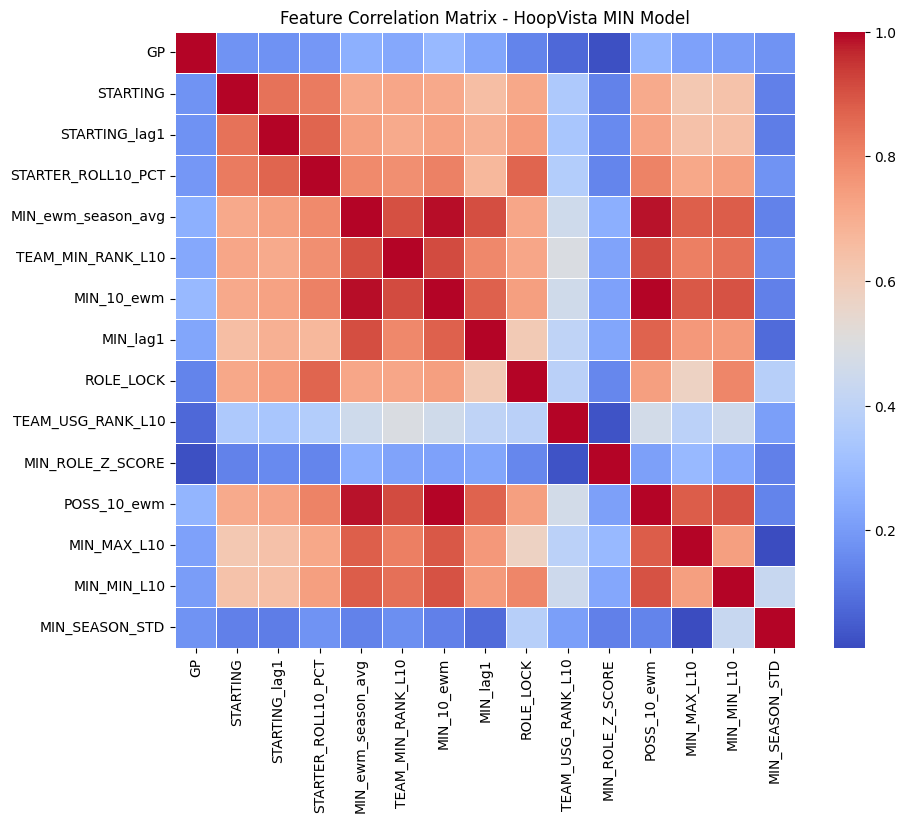

--- High Correlation Report (Threshold > 0.95) ---
POSS_10_ewm <-> MIN_10_ewm: 0.9968
MIN_10_ewm <-> MIN_ewm_season_avg: 0.9917
POSS_10_ewm <-> MIN_ewm_season_avg: 0.9884


['MIN_10_ewm', 'POSS_10_ewm']

In [13]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [14]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   MIN_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"min_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_minutes(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to min_quantile_xgb_2026-02-03.joblib
Loaded model MAE: 4.323
Trained on data up to: 2025-11-24 00:00:00
Validated on data up to: 2026-02-03 00:00:00
